<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset2_IDS_2018_without_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/CSE-CIC-IDS2018'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder
all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path) for filename in filenames]

## Step 2: Labelling the Dataset as Fraud-only, DDoS-only, Fraud-under-DDoS and Benign

In [ ]:
ids2018_labels = [
    'Benign', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC',
    'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye',
    'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris',
    'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce'
]


ddos_attacks = [
    'DDOS attack-HOIC',
    'DDOS attack-LOIC-UDP',
    'DDoS attacks-LOIC-HTTP',
    'DoS attacks-GoldenEye',
    'DoS attacks-Hulk',
    'DoS attacks-SlowHTTPTest',
    'DoS attacks-Slowloris'
]

fraud_attacks = [
    'Brute Force -Web',
    'Brute Force -XSS',
    'FTP-BruteForce',
    'SSH-Bruteforce',
    'SQL Injection',
    'Infilteration'
]
path = 'Dataset'
all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path)
             for filename in filenames if filename.endswith('.csv')]
def get_sample_size(file_size, filename):
    if file_size > 1000000:
        return 20000
    elif file_size > 100000:
        return min(15000, file_size)
    else:
        return None
common_columns = None
file_columns = {}
file_sizes = {}
for file_path in all_files:
    try:
        file_size = sum(1 for line in open(file_path)) - 1
        file_sizes[file_path] = file_size
        df_sample = pd.read_csv(file_path, nrows=1)
        file_columns[file_path] = set(df_sample.columns)
        if common_columns is None:
            common_columns = set(df_sample.columns)
        else:
            common_columns = common_columns.intersection(set(df_sample.columns))
    except Exception as e:
        print(f"Error reading headers from {file_path}: {e}")
if common_columns:
    for col in sorted(common_columns):
        pass
else:
    print("No common columns found across files!")
    exit()
all_dfs = []
total_rows_before_sampling = 0
total_rows_after_sampling = 0
for file_path in all_files:
    try:
        file_size = file_sizes[file_path]
        sample_size = get_sample_size(file_size, os.path.basename(file_path))
        total_rows_before_sampling += file_size
        if sample_size and file_size > sample_size:
            skip_rows = lambda i: i > 0 and np.random.rand() > (sample_size / file_size)
            try:
                df = pd.read_csv(file_path, usecols=list(common_columns), skiprows=skip_rows)
                if len(df) > sample_size:
                    df = df.sample(n=sample_size, random_state=42)
            except:
                df = pd.read_csv(file_path, usecols=list(common_columns), nrows=sample_size*2)
                df = df.sample(n=min(sample_size, len(df)), random_state=42)
        else:
            df = pd.read_csv(file_path, usecols=list(common_columns))
        if 'Label' not in df.columns:
            continue
        total_rows_after_sampling += len(df)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
if not all_dfs:
    pass
    exit()
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df['is_ddos'] = combined_df['Label'].apply(lambda x: 1 if x in ddos_attacks else 0)
combined_df['is_fraud'] = combined_df['Label'].apply(lambda x: 1 if x in fraud_attacks else 0)
combined_df.reset_index(drop=True, inplace=True)
combined_df['timestamp'] = pd.to_datetime(combined_df.index, unit='s')
combined_df['window'] = combined_df['timestamp'].dt.floor('1min')
ddos_windows = combined_df[combined_df['is_ddos'] == 1].groupby('window').size()
threshold = ddos_windows.quantile(0.75) if len(ddos_windows) > 0 else 0
active_ddos_windows = set(ddos_windows[ddos_windows > threshold].index) if len(ddos_windows) > 0 else set()
fraud_windows = combined_df[combined_df['is_fraud'] == 1].groupby('window').size()
fraud_threshold = fraud_windows.quantile(0.75) if len(fraud_windows) > 0 else 0
active_fraud_windows = set(fraud_windows[fraud_windows > fraud_threshold].index) if len(fraud_windows) > 0 else set()
quantiles = {}
if 'Flow Duration' in combined_df.columns:
    quantiles['Flow Duration'] = combined_df['Flow Duration'].quantile(0.90)
flow_bytes_col = None
for possible_col in ['Flow Byts/s', 'Flow Bytes/s', 'Flow Byts', 'Flow Bytes']:
    if possible_col in combined_df.columns:
        flow_bytes_col = possible_col
        quantiles[flow_bytes_col] = combined_df[flow_bytes_col].quantile(0.90)
        break
if 'Fwd IAT Mean' in combined_df.columns:
    quantiles['Fwd IAT Mean'] = combined_df['Fwd IAT Mean'].quantile(0.90)
if 'Idle Max' in combined_df.columns:
    quantiles['Idle Max'] = combined_df['Idle Max'].quantile(0.90)
def fraud_score_optimized(row):
    score = 0
    try:
        if 'Flow Duration' in quantiles and pd.notna(row['Flow Duration']) and row['Flow Duration'] > quantiles['Flow Duration']:
            score += 1
        if flow_bytes_col and flow_bytes_col in quantiles and pd.notna(row[flow_bytes_col]) and row[flow_bytes_col] > quantiles[flow_bytes_col]:
            score += 1
        if 'Fwd IAT Mean' in quantiles and pd.notna(row['Fwd IAT Mean']) and row['Fwd IAT Mean'] > quantiles['Fwd IAT Mean']:
            score += 1
        psh_col, urg_col = None, None
        for possible_psh in ['Fwd PSH Flags', 'Fwd PSH Flag', 'PSH Flag Cnt']:
            if possible_psh in combined_df.columns:
                psh_col = possible_psh
                break
        for possible_urg in ['URG Flag Cnt', 'URG Flag Count', 'Fwd URG Flags']:
            if possible_urg in combined_df.columns:
                urg_col = possible_urg
                break
        if psh_col and urg_col and pd.notna(row[psh_col]) and pd.notna(row[urg_col]) and (row[psh_col] > 0 or row[urg_col] > 0):
            score += 1
        elif psh_col and pd.notna(row[psh_col]) and row[psh_col] > 0:
            score += 1
        elif urg_col and pd.notna(row[urg_col]) and row[urg_col] > 0:
            score += 1
        if 'Idle Max' in quantiles and pd.notna(row['Idle Max']) and row['Idle Max'] > quantiles['Idle Max']:
            score += 1
    except Exception as e:
        pass
    return score
batch_size = 10000
fraud_scores = []
for i in range(0, len(combined_df), batch_size):
    batch = combined_df.iloc[i:i+batch_size]
    batch_scores = batch.apply(fraud_score_optimized, axis=1)
    fraud_scores.extend(batch_scores)
combined_df['fraud_score'] = fraud_scores
FRAUD_THRESHOLD = 2
def assign_final_label(row):
    original_label = row['Label']
    if row['fraud_score'] >= FRAUD_THRESHOLD:
        if original_label in ddos_attacks and row['window'] in active_ddos_windows:
            return 'Fraud-under-DDoS'
        elif original_label in fraud_attacks:
            return 'Fraud-only'
        else:
            return 'Benign'
    else:
        if original_label in ddos_attacks:
            return 'DDoS-only'
        elif original_label in fraud_attacks:
            return 'Fraud-only'
        else:
            return 'Benign'
final_labels = []
for i in range(0, len(combined_df), batch_size):
    batch = combined_df.iloc[i:i+batch_size]
    batch_labels = batch.apply(assign_final_label, axis=1)
    final_labels.extend(batch_labels)
combined_df['Final_Label'] = final_labels
csv_save_path = "IDS2018.csv"
combined_df.to_csv(csv_save_path, index=False)
final_distribution = combined_df['Final_Label'].value_counts()
for label, count in final_distribution.items():
    percentage = (count / len(combined_df)) * 100
cross_tab = pd.crosstab(combined_df['Label'], combined_df['Final_Label'])

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
df = pd.read_csv('/content/IDS2018.csv')
drop_cols = ['timestamp', 'window', 'fraud_score', 'is_ddos', 'Label']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
constant_cols = df.columns[df.nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Final_Label'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Label_encoded')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
X = df[numeric_cols].values
y = to_categorical(df['Label_encoded'].values)
X = X.reshape((X.shape[0], 1, X.shape[1]))

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 5: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=64,
    verbose=1
)

Epoch 1/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.9650 - loss: 0.1086 - val_accuracy: 0.9966 - val_loss: 0.0114
Epoch 2/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.9970 - loss: 0.0108 - val_accuracy: 0.9988 - val_loss: 0.0048
Epoch 3/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9981 - val_loss: 0.0061
Epoch 4/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9981 - loss: 0.0075 - val_accuracy: 0.9982 - val_loss: 0.0057
Epoch 5/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9982 - loss: 0.0068 - val_accuracy: 0.9989 - val_loss: 0.0041
Epoch 6/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 0.9988 - val_loss: 0.0044
Epoch 7/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9985 - loss: 0.0061 - val_accuracy: 0.9987 - val_loss: 0.0045
Epoch 8/150
2506/2506 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9984 -

## Step 6: Evaluate Proposed Model

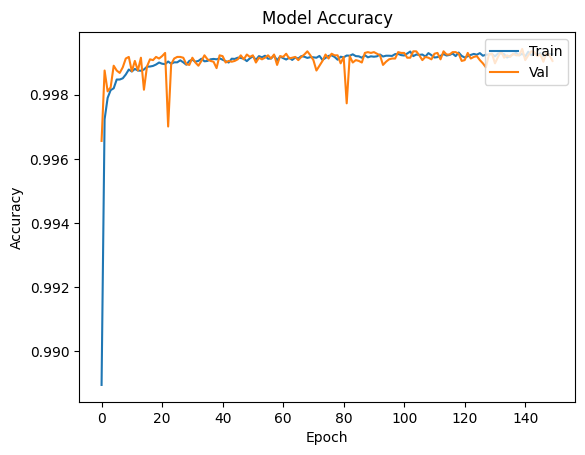

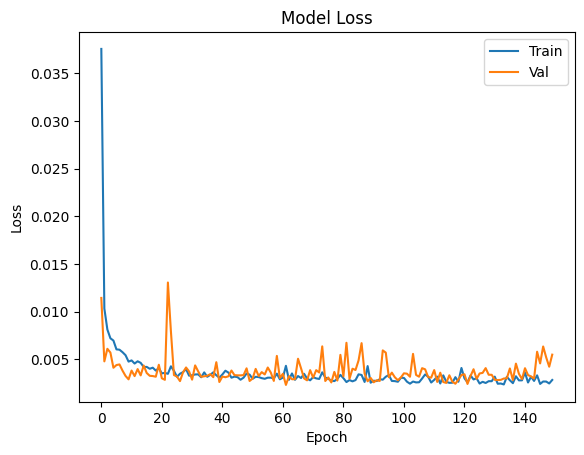

1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00     29573
       DDoS-only       1.00      1.00      1.00      5695
      Fraud-only       1.00      1.00      1.00      2954
Fraud-under-DDoS       0.99      0.99      0.99      1867

        accuracy                           1.00     40089
       macro avg       1.00      1.00      1.00     40089
    weighted avg       1.00      1.00      1.00     40089



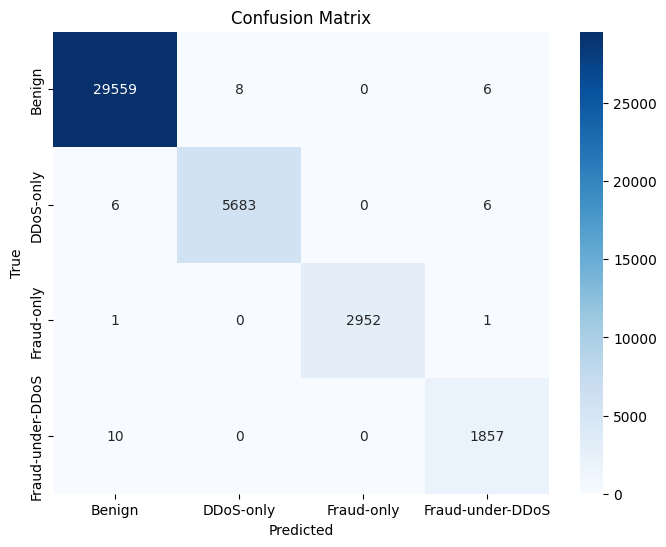

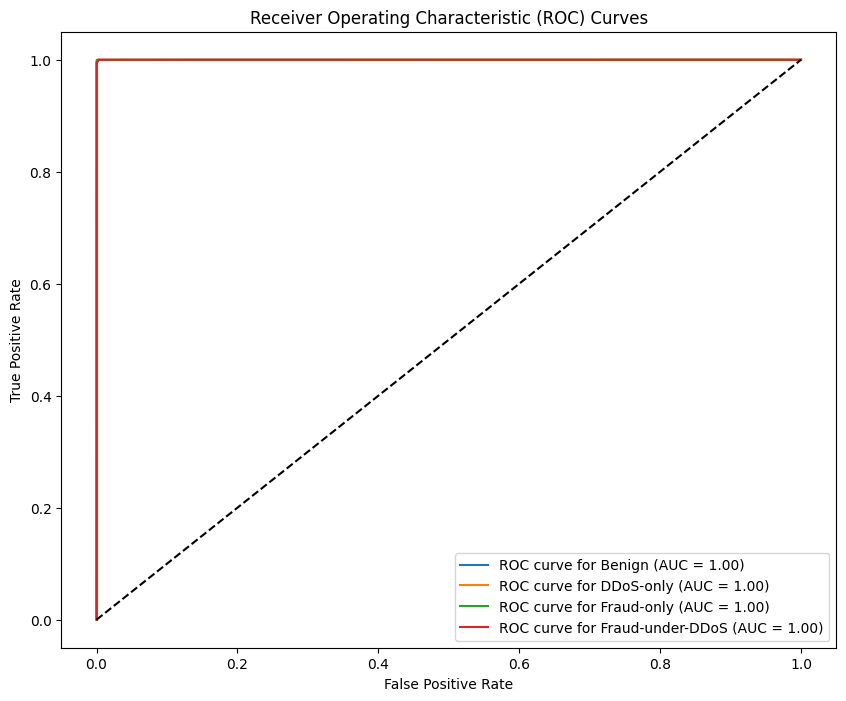


 AUC Score (OvR): 1.0000


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 7: Implementation of Proposed CADE-GF

## Step 7 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 7 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 7 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 8: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = numeric_cols
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

1253/1253 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Optimal threshold: 0.100
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
AUC (clean): 1.0000
AUC (evaded): 1.0000
AUC degradation: 0.0000
Evasion success rate: 0.0002
